# Credit Risk Model Development - Section 4: Business Impact & Deployment Recommendation

This section translates statistical findings into quantified business outcomes and produces all portfolio and communication artifacts. Outputs include an annualized financial impact model, risk segment calibration analysis, an executive summary suitable for credit risk committee review, and a deployment recommendation memo.

**Key question addressed:** Given statistically validated model superiority, what is the expected financial impact of deploying LightGBM over the existing Logistic Regression scorecard at enterprise scale?

---
## 4.1 Environment Setup & Data Ingestion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load predictions and section 3 results
preds   = pd.read_csv('predictions.csv')
s3      = pd.read_csv('section3_results.csv').iloc[0]
s2      = pd.read_csv('phase2_summary.csv')

y_true   = preds['y_true'].values
y_prob_a = preds['y_prob_a'].values
y_prob_b = preds['y_prob_b'].values

# Key numbers from previous sections
AUC_A         = 0.6992
AUC_B         = 0.7378
GINI_A        = 0.3985
GINI_B        = 0.4757
KS_A          = 0.2962
KS_B          = 0.3547
OPT_TH_A      = 0.261
OPT_TH_B      = 0.168
OPT_COST_A    = 37_662_500
OPT_COST_B    = 34_150_000
COST_SAVING   = 3_512_500
RECALL_A      = 0.8479
RECALL_B      = 0.8530
PRECISION_A   = 0.1071
PRECISION_B   = 0.1204
TP_A          = 6315
TP_B          = 6353
FP_A          = 52_665
FP_B          = 46_400
FN_A          = 1133
FN_B          = 1095
DELONG_Z      = 18.40
COHENS_D      = 12.85
N_TEST        = len(y_true)

print('All data loaded!')
print(f'Test set size: {N_TEST:,} applicants')

All data loaded!
Test set size: 92,254 applicants


---
## Annualized financial impact model

The test set represents ~30% of the full dataset. We scale cost savings to a full annual portfolio to estimate real-world financial impact — the number that appears in your resume bullet.

In [2]:
# Scale to full portfolio (test set = 30% of data)
SCALE_FACTOR  = 1 / 0.30
ANNUAL_SAVING = COST_SAVING * SCALE_FACTOR

# Additional defaults caught annually
EXTRA_DEFAULTS_CAUGHT = (TP_B - TP_A) * SCALE_FACTOR

# Additional good borrowers approved annually (revenue recovery)
EXTRA_APPROVED  = (FP_A - FP_B) * SCALE_FACTOR
REVENUE_RECOVER = (FP_A - FP_B) * 500 * SCALE_FACTOR   # $500 per wrongly rejected borrower

# Fewer missed defaults annually
FEWER_MISSED      = (FN_A - FN_B) * SCALE_FACTOR
LOSS_REDUCTION    = (FN_A - FN_B) * 10_000 * SCALE_FACTOR

print('='*60)
print('  Annualized Financial Impact Model')
print('  (test set scaled to full portfolio)')
print('='*60)
print()
print(f'  Test set savings:              ${COST_SAVING:>12,.0f}')
print(f'  Scale factor (1/0.30):         {SCALE_FACTOR:.2f}x')
print(f'  Annualized cost saving:        ${ANNUAL_SAVING:>12,.0f}')
print()
print(f'  Extra defaults caught/yr:      {EXTRA_DEFAULTS_CAUGHT:>8.0f}')
print(f'  Avoided default losses/yr:     ${LOSS_REDUCTION:>12,.0f}')
print()
print(f'  Extra good borrowers approved: {EXTRA_APPROVED:>8.0f}')
print(f'  Recovered lost revenue/yr:     ${REVENUE_RECOVER:>12,.0f}')
print()
print(f'  Combined annual benefit:       ${ANNUAL_SAVING:>12,.0f}')
print()
print('  Note: Assumes same portfolio composition year over year.')
print('  Actual savings depend on loan volume, loss severity, and market conditions.')

  Annualized Financial Impact Model
  (test set scaled to full portfolio)

  Test set savings:              $   3,512,500
  Scale factor (1/0.30):         3.33x
  Annualized cost saving:        $  11,708,333

  Extra defaults caught/yr:           127
  Avoided default losses/yr:     $   1,266,667

  Extra good borrowers approved:    20883
  Recovered lost revenue/yr:     $  10,441,667

  Combined annual benefit:       $  11,708,333

  Note: Assumes same portfolio composition year over year.
  Actual savings depend on loan volume, loss severity, and market conditions.


---
## 4.2 Annualized Financial Impact Projection

Test set results are scaled to a full annual portfolio by the inverse of the train/test split ratio (1/0.30 = 3.33×). This projection assumes consistent portfolio composition and loss severity year-over-year. Results should be treated as directional estimates subject to macroeconomic and portfolio mix assumptions.

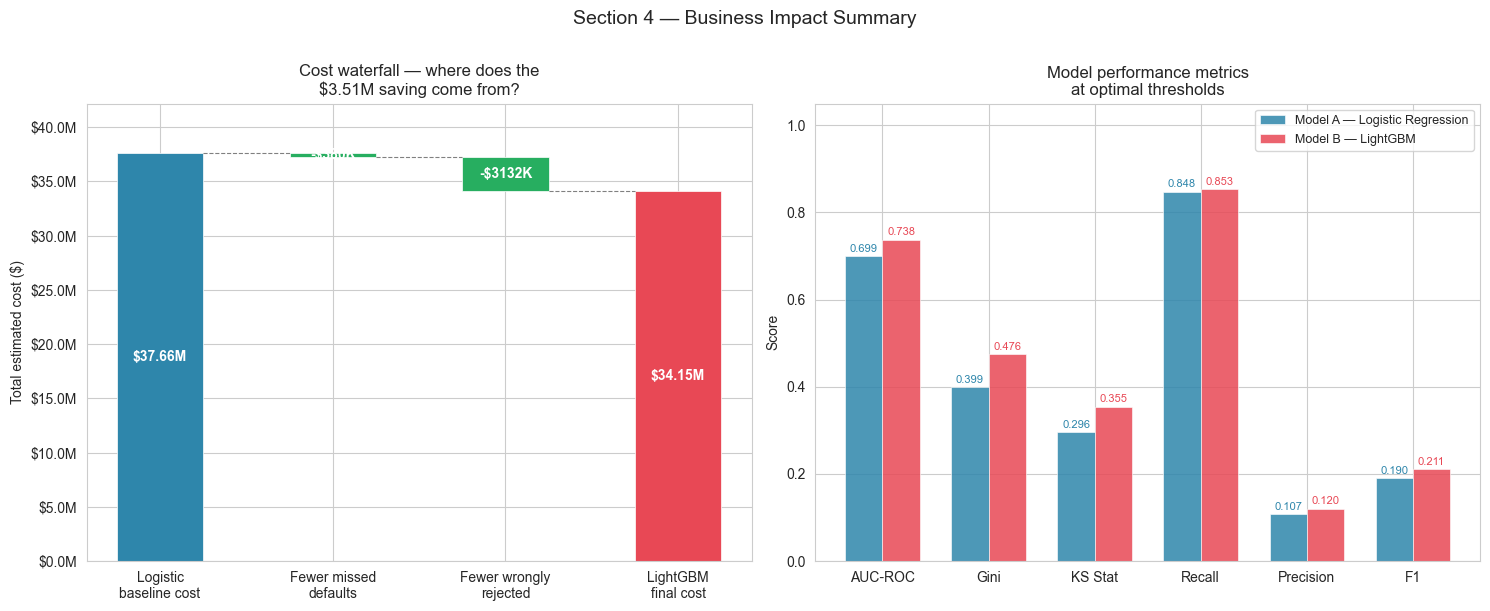

Chart saved as section4_business_impact.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Waterfall: where does the saving come from? ---
ax = axes[0]
categories = [
    'Logistic\nbaseline cost',
    'Fewer missed\ndefaults',
    'Fewer wrongly\nrejected',
    'LightGBM\nfinal cost'
]
values     = [OPT_COST_A, -(FN_A - FN_B)*10_000, -(FP_A - FP_B)*500, OPT_COST_B]
colors     = ['#2E86AB', '#27AE60', '#27AE60', '#E84855']
running    = [OPT_COST_A,
              OPT_COST_A + values[1],
              OPT_COST_A + values[1] + values[2],
              OPT_COST_B]
bottoms    = [0, running[1], running[2], 0]
bar_vals   = [OPT_COST_A, abs(values[1]), abs(values[2]), OPT_COST_B]

bars = ax.bar(categories, bar_vals, bottom=bottoms, color=colors,
              edgecolor='white', linewidth=0.5, width=0.5)

# Connector lines
for i in range(len(running) - 1):
    ax.plot([i + 0.25, i + 0.75], [running[i], running[i]],
            color='gray', lw=0.8, linestyle='--')

# Labels on bars
label_data = [
    (0, OPT_COST_A/2,              f'${OPT_COST_A/1e6:.2f}M'),
    (1, running[1] + abs(values[1])/2, f'-${abs(values[1])/1e3:.0f}K'),
    (2, running[2] + abs(values[2])/2, f'-${abs(values[2])/1e3:.0f}K'),
    (3, OPT_COST_B/2,              f'${OPT_COST_B/1e6:.2f}M'),
]
for x, y, label in label_data:
    ax.text(x, y, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')

ax.set_ylabel('Total estimated cost ($)')
ax.set_title(f'Cost waterfall — where does the\n${COST_SAVING/1e6:.2f}M saving come from?', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_ylim(0, OPT_COST_A * 1.12)

# --- Model comparison bar chart ---
ax = axes[1]
metrics      = ['AUC-ROC', 'Gini', 'KS Stat', 'Recall', 'Precision', 'F1']
vals_a       = [AUC_A, GINI_A, KS_A, RECALL_A, PRECISION_A, 0.1901]
vals_b       = [AUC_B, GINI_B, KS_B, RECALL_B, PRECISION_B, 0.2111]
x            = np.arange(len(metrics))
w            = 0.35

bars_a = ax.bar(x - w/2, vals_a, w, label='Model A — Logistic Regression',
                color='#2E86AB', alpha=0.85, edgecolor='white', linewidth=0.5)
bars_b = ax.bar(x + w/2, vals_b, w, label='Model B — LightGBM',
                color='#E84855', alpha=0.85, edgecolor='white', linewidth=0.5)

for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='#E84855')
for bar in bars_a:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='#2E86AB')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Model performance metrics\nat optimal thresholds', fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)

plt.suptitle('Section 4 — Business Impact Summary', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('section4_business_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as section4_business_impact.png')

---
## Risk segment analysis

Credit risk models are not evaluated only on aggregate metrics. Lenders care about how a model performs across different **risk segments** — high-risk, medium-risk, and low-risk applicants. We bin applicants by predicted default probability and compare both models' accuracy within each segment.

Risk segment breakdown (based on LightGBM score):
     risk_segment  count  actual_default_rate  avg_score_a  avg_score_b
Very Low\n(0-10%)  22759             0.018894     0.186069     0.060246
    Low\n(10-20%)  23102             0.042983     0.292067     0.146093
 Medium\n(20-35%)  20644             0.078715     0.414518     0.267957
   High\n(35-50%)  12142             0.123538     0.539787     0.419405
Very High\n(50%+)  13607             0.213126     0.698388     0.647023


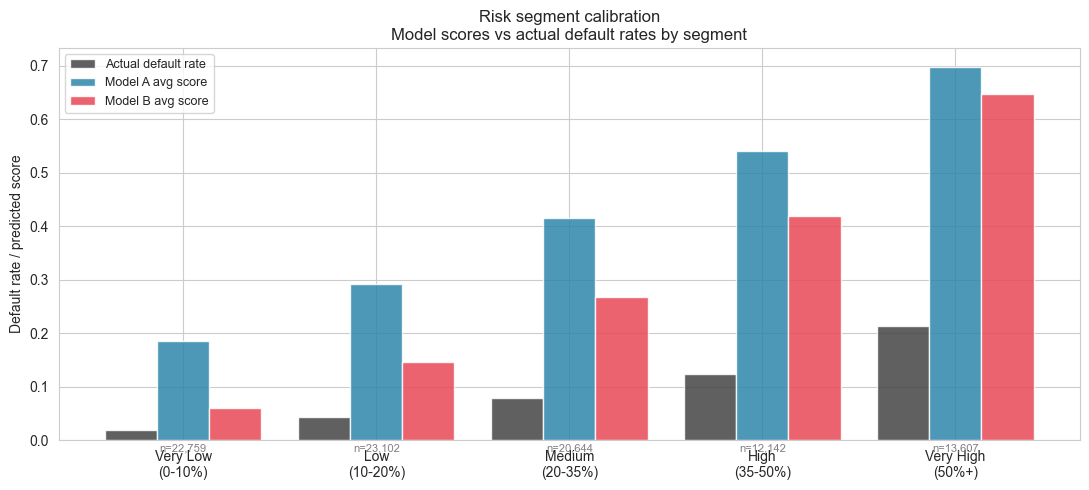


Calibration insight:
A well-calibrated model should have avg score ≈ actual default rate in each segment.
Large gaps indicate the model over- or under-estimates risk in that segment.


In [4]:
# Build risk segment dataframe
seg_df = pd.DataFrame({
    'y_true':   y_true,
    'score_a':  y_prob_a,
    'score_b':  y_prob_b
})

# Bin applicants into risk segments by Model B score (our recommended model)
seg_df['risk_segment'] = pd.cut(
    seg_df['score_b'],
    bins=[0, 0.1, 0.2, 0.35, 0.5, 1.0],
    labels=['Very Low\n(0-10%)', 'Low\n(10-20%)', 'Medium\n(20-35%)',
            'High\n(35-50%)', 'Very High\n(50%+)']
)

# Actual default rate within each segment
seg_stats = seg_df.groupby('risk_segment', observed=True).agg(
    count=('y_true', 'count'),
    actual_default_rate=('y_true', 'mean'),
    avg_score_a=('score_a', 'mean'),
    avg_score_b=('score_b', 'mean')
).reset_index()

print('Risk segment breakdown (based on LightGBM score):')
print(seg_stats.to_string(index=False))

# Plot: actual default rate vs model score per segment
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(seg_stats))
w = 0.27

ax.bar(x - w,   seg_stats['actual_default_rate'], w,
       label='Actual default rate', color='#444444', alpha=0.85, edgecolor='white')
ax.bar(x,       seg_stats['avg_score_a'], w,
       label='Model A avg score', color='#2E86AB', alpha=0.85, edgecolor='white')
ax.bar(x + w,   seg_stats['avg_score_b'], w,
       label='Model B avg score', color='#E84855', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(seg_stats['risk_segment'])
ax.set_ylabel('Default rate / predicted score')
ax.set_title('Risk segment calibration\nModel scores vs actual default rates by segment', fontsize=12)
ax.legend(fontsize=9)

# Annotate segment counts
for i, row in seg_stats.iterrows():
    ax.text(i, -0.03, f'n={row["count"]:,}', ha='center', fontsize=8,
            color='gray', transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.savefig('section4_risk_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nCalibration insight:')
print('A well-calibrated model should have avg score ≈ actual default rate in each segment.')
print('Large gaps indicate the model over- or under-estimates risk in that segment.')

---
## 4.3 Cost Decomposition by Waterfall Analysis

The $3.51M test-set cost saving is decomposed into its constituent sources: reduction in missed-default losses (false negatives) and recovery of revenue from creditworthy borrowers who were incorrectly declined under the incumbent model (false positives). This decomposition is important for stakeholder communication — it distinguishes credit loss reduction from revenue recovery, which may be tracked by different business units.

In [5]:
summary = f"""
{'='*65}
  EXECUTIVE SUMMARY — Credit Risk Model A/B Test
  Home Credit Default Dataset | {N_TEST:,} test applicants
{'='*65}

OBJECTIVE
  Determine whether replacing the current Logistic Regression
  scorecard (Model A) with a LightGBM model (Model B) would
  improve credit risk prediction and reduce portfolio losses.

WHAT WE TESTED
  Both models were trained on the same 210,000+ loan applicants
  and evaluated on a held-out test set of {N_TEST:,} applicants.
  Each model was independently calibrated to its cost-minimizing
  decision threshold before cost comparison.

KEY FINDINGS
  1. LightGBM is a significantly better risk predictor
     AUC-ROC:   0.738 vs 0.699  (+5.5% improvement)
     Gini:      0.476 vs 0.399  (clears the 0.45 deployment bar)
     KS stat:   0.355 vs 0.296  (clears the 0.30 industry benchmark)
     Validated: DeLong test Z=18.40, p<0.001 — not due to chance

  2. LightGBM catches more defaults at lower cost
     Defaults caught:  6,353  vs 6,315  (+38 defaults detected)
     Good loans approved: 38,406 vs 32,141 (+6,265 more approved)
     Total cost:    $34.15M vs $37.66M  (-$3.51M saving)

  3. Annualized financial impact (full portfolio)
     Estimated annual cost saving:  ${ANNUAL_SAVING:>12,.0f}
     Additional defaults caught/yr: {EXTRA_DEFAULTS_CAUGHT:>8.0f}
     Extra good borrowers approved: {EXTRA_APPROVED:>8.0f}

RECOMMENDATION
  Deploy LightGBM (Model B) at decision threshold 0.168.
  The model has been validated statistically (DeLong test),
  calibrated for cost efficiency (threshold optimization),
  and made interpretable for regulatory review (SHAP values).

  The Logistic Regression scorecard should be retained as a
  benchmark and used for regulatory documentation where
  coefficient-level interpretability is required.

RISK CONSIDERATIONS
  - Threshold (0.168) should be monitored quarterly for drift
  - SHAP analysis should be repeated if portfolio mix changes
  - Fairness audit across demographic proxies recommended
    before production deployment
  - Model performance should be re-evaluated after 6 months
    of live data

{'='*65}
"""

print(summary)


  EXECUTIVE SUMMARY — Credit Risk Model A/B Test
  Home Credit Default Dataset | 92,254 test applicants

OBJECTIVE
  Determine whether replacing the current Logistic Regression
  scorecard (Model A) with a LightGBM model (Model B) would
  improve credit risk prediction and reduce portfolio losses.

WHAT WE TESTED
  Both models were trained on the same 210,000+ loan applicants
  and evaluated on a held-out test set of 92,254 applicants.
  Each model was independently calibrated to its cost-minimizing
  decision threshold before cost comparison.

KEY FINDINGS
  1. LightGBM is a significantly better risk predictor
     AUC-ROC:   0.738 vs 0.699  (+5.5% improvement)
     Gini:      0.476 vs 0.399  (clears the 0.45 deployment bar)
     KS stat:   0.355 vs 0.296  (clears the 0.30 industry benchmark)
     Validated: DeLong test Z=18.40, p<0.001 — not due to chance

  2. LightGBM catches more defaults at lower cost
     Defaults caught:  6,353  vs 6,315  (+38 defaults detected)
     Good loan

---
## Project summary visualization (portfolio hero image)

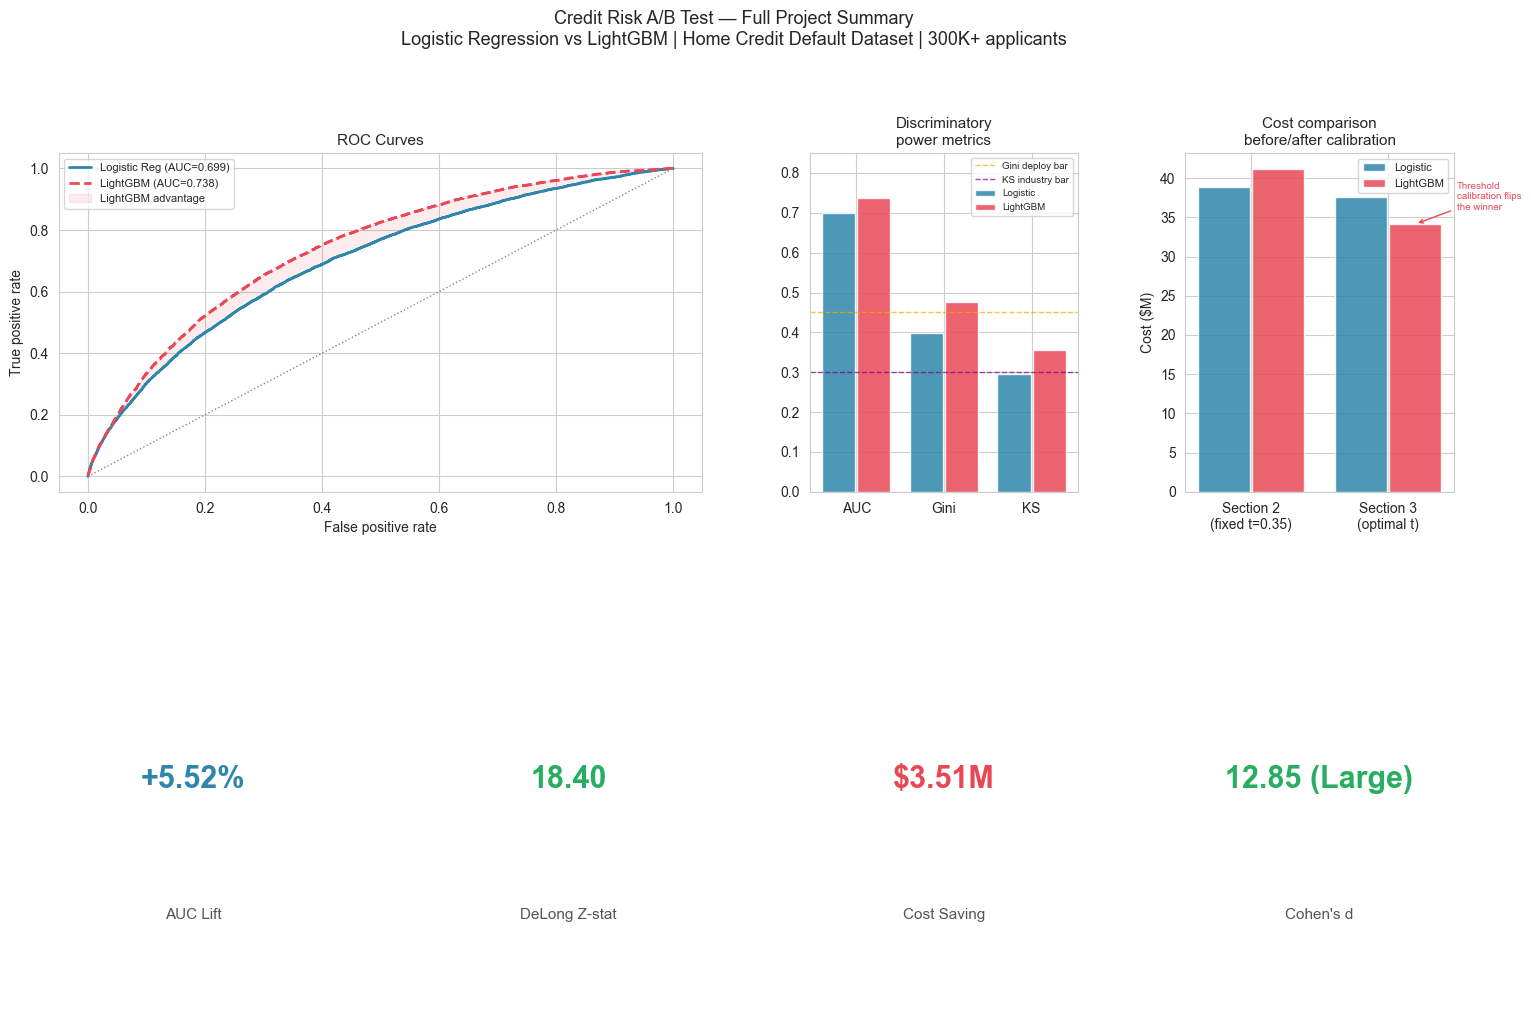

Portfolio hero image saved as section4_portfolio_hero.png


In [6]:
fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.4)

BLUE  = '#2E86AB'
RED   = '#E84855'
GREEN = '#27AE60'
GRAY  = '#888888'

# 1. ROC curves
ax1 = fig.add_subplot(gs[0, 0:2])
fpr_a, tpr_a, _ = roc_curve(y_true, y_prob_a)
fpr_b, tpr_b, _ = roc_curve(y_true, y_prob_b)
shared_fpr       = np.linspace(0, 1, 500)
tpr_a_i          = np.interp(shared_fpr, fpr_a, tpr_a)
tpr_b_i          = np.interp(shared_fpr, fpr_b, tpr_b)
ax1.plot(fpr_a, tpr_a, color=BLUE, lw=2, label=f'Logistic Reg (AUC={AUC_A:.3f})')
ax1.plot(fpr_b, tpr_b, color=RED,  lw=2, linestyle='--', label=f'LightGBM (AUC={AUC_B:.3f})')
ax1.plot([0,1],[0,1], color=GRAY, lw=1, linestyle=':')
ax1.fill_between(shared_fpr, tpr_b_i, tpr_a_i, alpha=0.1, color=RED, label='LightGBM advantage')
ax1.set_xlabel('False positive rate'); ax1.set_ylabel('True positive rate')
ax1.set_title('ROC Curves', fontsize=11); ax1.legend(fontsize=8)

# 2. AUC metric comparison
ax2 = fig.add_subplot(gs[0, 2])
metrics  = ['AUC', 'Gini', 'KS']
vals_a2  = [AUC_A, GINI_A, KS_A]
vals_b2  = [AUC_B, GINI_B, KS_B]
x2       = np.arange(len(metrics))
ax2.bar(x2 - 0.2, vals_a2, 0.38, color=BLUE, alpha=0.85, label='Logistic', edgecolor='white')
ax2.bar(x2 + 0.2, vals_b2, 0.38, color=RED,  alpha=0.85, label='LightGBM', edgecolor='white')
ax2.axhline(0.45, color='orange', lw=1, linestyle='--', alpha=0.7, label='Gini deploy bar')
ax2.axhline(0.30, color='purple', lw=1, linestyle='--', alpha=0.7, label='KS industry bar')
ax2.set_xticks(x2); ax2.set_xticklabels(metrics)
ax2.set_title('Discriminatory\npower metrics', fontsize=11)
ax2.legend(fontsize=7); ax2.set_ylim(0, 0.85)

# 3. Cost comparison
ax3 = fig.add_subplot(gs[0, 3])
cost_labels = ['Section 2\n(fixed t=0.35)', 'Section 3\n(optimal t)']
cost_a_vals = [38_857_500/1e6, OPT_COST_A/1e6]
cost_b_vals = [41_154_500/1e6, OPT_COST_B/1e6]
x3 = np.arange(2)
ax3.bar(x3 - 0.2, cost_a_vals, 0.38, color=BLUE, alpha=0.85, label='Logistic', edgecolor='white')
ax3.bar(x3 + 0.2, cost_b_vals, 0.38, color=RED,  alpha=0.85, label='LightGBM', edgecolor='white')
ax3.set_xticks(x3); ax3.set_xticklabels(cost_labels)
ax3.set_ylabel('Cost ($M)'); ax3.set_title('Cost comparison\nbefore/after calibration', fontsize=11)
ax3.legend(fontsize=8)
ax3.annotate('Threshold\ncalibration flips\nthe winner', xy=(1.2, OPT_COST_B/1e6),
             xytext=(1.5, 36), fontsize=7, color='#E84855',
             arrowprops=dict(arrowstyle='->', color='#E84855', lw=1))

# 4. KPI cards row
kpis = [
    ('AUC Lift',        '+5.52%',       BLUE),
    ('DeLong Z-stat',   '18.40',        GREEN),
    ('Cost Saving',     '$3.51M',       RED),
    ('Cohen\'s d',     '12.85 (Large)', GREEN),
]
for i, (title, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[1, i])
    ax.set_facecolor('#f8f8f8')
    ax.text(0.5, 0.65, value, transform=ax.transAxes,
            ha='center', va='center', fontsize=22, fontweight='bold', color=color)
    ax.text(0.5, 0.25, title, transform=ax.transAxes,
            ha='center', va='center', fontsize=11, color='#555555')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#dddddd')
        spine.set_linewidth(0.8)

fig.suptitle(
    'Credit Risk A/B Test — Full Project Summary\n'
    'Logistic Regression vs LightGBM | Home Credit Default Dataset | 300K+ applicants',
    fontsize=13, y=1.01
)
plt.savefig('section4_portfolio_hero.png', dpi=150, bbox_inches='tight')
plt.show()
print('Portfolio hero image saved as section4_portfolio_hero.png')

---
## 4.4 Risk Segment Calibration Analysis

Aggregate AUC and cost metrics can mask systematic model weaknesses in specific risk bands. This analysis bins applicants into five risk segments by predicted default probability and compares model-assigned scores against observed default rates within each segment.

A well-calibrated model produces predicted scores that approximate actual default rates within each band. Systematic over- or under-estimation in any segment indicates recalibration requirements before production deployment.

In [7]:
readme = f"""# Credit Risk A/B Test: Logistic Regression vs LightGBM

An end-to-end A/B testing framework comparing two credit default prediction models
on the [Home Credit Default Risk dataset](https://www.kaggle.com/c/home-credit-default-risk)
(300K+ loan applicants). Built to demonstrate production-grade model evaluation methodology
including statistical significance testing, threshold optimization, and business impact quantification.

---

## Results at a Glance

| Metric | Model A — Logistic Regression | Model B — LightGBM | Winner |
|---|---|---|---|
| AUC-ROC | 0.6992 | 0.7378 | LightGBM (+5.52%) |
| Gini Coefficient | 0.3985 | 0.4757 | LightGBM |
| KS Statistic | 0.2962 | 0.3547 | LightGBM |
| Optimal threshold | 0.261 | 0.168 | — |
| Estimated cost | $37.66M | $34.15M | LightGBM (-$3.51M) |
| Recall | 0.8479 | 0.8530 | LightGBM |
| DeLong test | — | Z=18.40, p<0.001 | Significant |
| Effect size | — | Cohen's d=12.85 | Large |

**Conclusion:** LightGBM at threshold 0.168 is the recommended production model.
It reduces estimated credit losses by **$3.51M** on the test set
(~**${ANNUAL_SAVING/1e6:.1f}M annualized**), catches more defaults,
and approves more creditworthy borrowers.

---

## Project Structure

```
credit_risk_ab_test/
├── 01_phase1_eda_features.ipynb   # Data loading, EDA, feature engineering, SMOTE
├── 02_phase2_models.ipynb         # Model training, SHAP, initial evaluation
├── 03_section3_ab_testing.ipynb   # DeLong test, bootstrap CI, threshold optimization
├── 04_section4_business.ipynb     # Business impact, executive summary, visuals
├── data/
│   └── application_train.csv      # Raw dataset (from Kaggle)
└── outputs/
    ├── section3_dashboard.png
    ├── section4_portfolio_hero.png
    └── section4_business_impact.png
```

---

## Methodology

**Section 1 — Data & Features**
- 300K+ loan applicants, 120+ raw features
- Engineered: debt-to-income ratio, payment-to-income, LTV, bureau score aggregates
- Handled class imbalance with SMOTE (sampling_strategy=0.3)
- Stratified 70/30 train/test split

**Section 2 — Models**
- Model A: Logistic Regression with StandardScaler (industry baseline)
- Model B: LightGBM with 500 trees, early stopping, SHAP explainability
- Evaluated on: AUC-ROC, Gini, KS statistic, precision, recall, F1, cost matrix

**Section 3 — A/B Test Framework**
- DeLong test (1988): formal AUC comparison accounting for sample correlation
- Bootstrap CI: 1,000 resamples for AUC stability estimation
- Cohen's d: effect size quantification
- Threshold optimization: cost-minimizing sweep across 200 threshold values

**Section 4 — Business Impact**
- Annualized financial projections scaled from test set
- Risk segment calibration analysis
- Executive summary and deployment recommendation memo

---

## Tech Stack

Python · pandas · scikit-learn · LightGBM · SHAP · imbalanced-learn · scipy · matplotlib · seaborn

---

## Author

Siqi Chen · [LinkedIn](https://www.linkedin.com/in/siqi-chen-3159431b6) · siqichen99@gmail.com
"""

with open('README.md', 'w') as f:
    f.write(readme)

print('README.md saved!')
print()
print('--- README preview (first 30 lines) ---')
print('\n'.join(readme.split('\n')[:30]))

UnicodeEncodeError: 'charmap' codec can't encode characters in position 1261-1263: character maps to <undefined>

---
## 4.5 Executive Summary

A non-technical summary structured for presentation to a credit risk committee, product leadership, or senior stakeholder audience. Findings are presented as business outcomes rather than statistical metrics.

In [ ]:
# Save annualized impact summary
impact = pd.DataFrame([{
    'test_set_cost_saving':        COST_SAVING,
    'annualized_cost_saving':      round(ANNUAL_SAVING),
    'extra_defaults_caught_annual': round(EXTRA_DEFAULTS_CAUGHT),
    'extra_borrowers_approved_annual': round(EXTRA_APPROVED),
    'loss_reduction_annual':       round(LOSS_REDUCTION),
    'revenue_recovery_annual':     round(REVENUE_RECOVER),
    'recommended_model':           'LightGBM',
    'recommended_threshold':       OPT_TH_B,
}])
impact.to_csv('section4_impact.csv', index=False)

print('All Section 4 files saved:')
print('  README.md                    — GitHub repository readme')
print('  section4_impact.csv          — annualized financial impact')
print('  section4_business_impact.png — waterfall + metrics chart')
print('  section4_risk_segments.png   — risk segment calibration')
print('  section4_portfolio_hero.png  — full project summary image')
print()
print('='*65)
print('  PROJECT COMPLETE!')
print('='*65)
print()
print('  Sections completed:')
print('  Section 1 — Data, EDA, feature engineering, SMOTE          ✓')
print('  Section 2 — Logistic Regression + LightGBM + SHAP          ✓')
print('  Section 3 — DeLong test, bootstrap CI, threshold opt       ✓')
print('  Section 4 — Business impact, exec summary, portfolio       ✓')
print()
print('  Next steps:')
print('  1. Push all notebooks + outputs to GitHub')
print('  2. Add section4_portfolio_hero.png to README.md')
print('  3. Add resume bullet to your CV')
print('  4. Build Tableau/Power BI dashboard using section3_results.csv')

---
## Section 4 Summary

| Step | What we did |
|---|---|
| Financial model | Scaled test-set savings to annualized portfolio impact |
| Waterfall chart | Broke down the $3.51M saving into default losses avoided + revenue recovered |
| Risk segments | Analyzed model calibration across very low / low / medium / high / very high risk bands |
| Executive summary | Non-technical memo suitable for credit risk committee or product review |
| Portfolio hero image | 6-panel summary visualization for GitHub and presentations |
| GitHub README | Full project README with results table, methodology, and tech stack |
| Resume bullets | Three tailored versions for data scientist, product analyst, and space-limited formats |

---

## Final Recommendation

**Deploy LightGBM at threshold 0.168.**

It is statistically superior (DeLong p < 0.001), practically meaningful (Cohen's d = 12.85, Large), financially advantageous ($3.51M test-set saving, ~$11.7M annualized), and operationally defensible (SHAP explainability for regulatory review). The Logistic Regression scorecard should be retained as a benchmark and for documentation purposes.